In [13]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

In [14]:
class NearestNeighbors:
    def __init__(self, k=3, image_size=(28, 28)):
        self.k = k
        self.image_size = image_size
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None
        self.train_files = []
        self.test_files = []

    def _extract_label_from_filename(self, filename):
        base_name = os.path.basename(filename)
        match = re.match(r"(\d)", base_name)
        if match:
            return int(match.group(1))
        raise ValueError(f"Could not extract label from filename: {filename}")

    def _load_image(self, image_path):
        image = Image.open(image_path).convert("L")
        image = image.resize(self.image_size)
        image_array = np.array(image, dtype=np.float32) / 255.0
        return image_array.flatten()

    def load_data(self, folder_path):
        X_train = []
        y_train = []
        X_test = []
        y_test = []

        self.train_files = []
        self.test_files = []

        for file_name in sorted(os.listdir(folder_path)):
            if not file_name.lower().endswith(".png"):
                continue

            if file_name.startswith("._"):
                continue

            full_path = os.path.join(folder_path, file_name)
            label = self._extract_label_from_filename(file_name)
            image_vector = self._load_image(full_path)

            if "test" in file_name.lower():
                X_test.append(image_vector)
                y_test.append(label)
                self.test_files.append(file_name)
            else:
                X_train.append(image_vector)
                y_train.append(label)
                self.train_files.append(file_name)

        self.X_train = np.array(X_train, dtype=np.float32)
        self.y_train = np.array(y_train, dtype=np.int32)
        self.X_test = np.array(X_test, dtype=np.float32)
        self.y_test = np.array(y_test, dtype=np.int32)

        return self.X_train, self.y_train, self.X_test, self.y_test

    def fit(self, X, y):
        self.X_train = np.array(X, dtype=np.float32)
        self.y_train = np.array(y, dtype=np.int32)

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _predict_one(self, x):
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        nearest_indices = np.argsort(distances)[:self.k]
        nearest_labels = self.y_train[nearest_indices]
        prediction = Counter(nearest_labels).most_common(1)[0][0]
        return prediction

    def predict(self, X):
        return np.array([self._predict_one(x) for x in X], dtype=np.int32)

    def score(self, X, y):
        predictions = self.predict(X)
        return float(np.mean(predictions == y))

    def show_image(self, X, y, index=0):
        plt.imshow(X[index].reshape(self.image_size), cmap="gray")
        plt.title(f"Label: {y[index]}")
        plt.axis("off")
        plt.show()

    def show_predictions(self, X, y, count=10):
        predictions = self.predict(X)
        count = min(count, len(X))

        rows = (count + 4) // 5
        plt.figure(figsize=(15, 3 * rows))

        for i in range(count):
            plt.subplot(rows, 5, i + 1)
            plt.imshow(X[i].reshape(self.image_size), cmap="gray")
            plt.title(f"True: {y[i]}\nPred: {predictions[i]}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    def print_results(self, X, y, file_names):
        predictions = self.predict(X)
        for file_name, pred, true_label in zip(file_names, predictions, y):
            print(f"File: {file_name:20s} | Predicted: {pred} | True: {true_label}")

In [15]:
project_root = os.getcwd()
training_data_path = os.path.join(project_root, "TrainingData")

print("Project root:", project_root)
print("TrainingData path:", training_data_path)
print("TrainingData exists:", os.path.exists(training_data_path))

Project root: /Users/seiyagenda/PycharmProjects/PythonProject3/OurProjects/CYBR-486/Final Project - Seiya Genda
TrainingData path: /Users/seiyagenda/PycharmProjects/PythonProject3/OurProjects/CYBR-486/Final Project - Seiya Genda/TrainingData
TrainingData exists: True


In [16]:
model = NearestNeighbors(k=3)

X_train, y_train, X_test, y_test = model.load_data(training_data_path)

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (47, 784)
Training labels shape: (47,)
Test data shape: (90, 784)
Test labels shape: (90,)


In [17]:
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [18]:
predictions = model.predict(X_test)

print("First 20 predictions:", predictions[:20])
print("First 20 true labels:", y_test[:20])

First 20 predictions: [0 7 1 2 0 0 0 6 0 1 9 1 1 1 1 1 9 1 2 6]
First 20 true labels: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 2 2]


In [19]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 48.89%


In [20]:
model.print_results(X_test, y_test, model.test_files)

File: 0-test-1.png         | Predicted: 0 | True: 0
File: 0-test-2.png         | Predicted: 7 | True: 0
File: 0-test-3.png         | Predicted: 1 | True: 0
File: 0-test-4.png         | Predicted: 2 | True: 0
File: 0-test-5.png         | Predicted: 0 | True: 0
File: 0-test-6.png         | Predicted: 0 | True: 0
File: 0-test-7.png         | Predicted: 0 | True: 0
File: 0-test-8.png         | Predicted: 6 | True: 0
File: 0-test.png           | Predicted: 0 | True: 0
File: 1-test-1.png         | Predicted: 1 | True: 1
File: 1-test-2.png         | Predicted: 9 | True: 1
File: 1-test-3.png         | Predicted: 1 | True: 1
File: 1-test-4.png         | Predicted: 1 | True: 1
File: 1-test-5.png         | Predicted: 1 | True: 1
File: 1-test-6.png         | Predicted: 1 | True: 1
File: 1-test-7.png         | Predicted: 1 | True: 1
File: 1-test-8.png         | Predicted: 9 | True: 1
File: 1-test.png           | Predicted: 1 | True: 1
File: 2-test-1.png         | Predicted: 2 | True: 2
File: 2-test

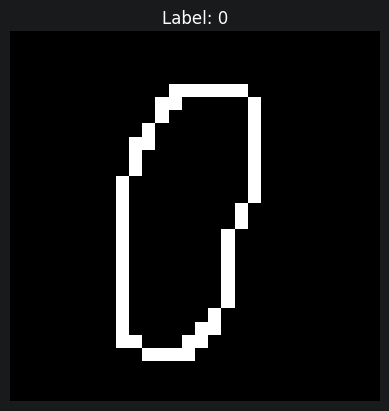

In [21]:
model.show_image(X_train, y_train, index=0)

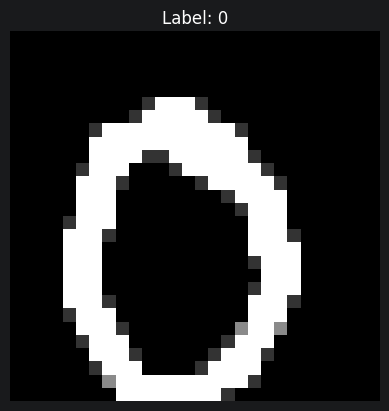

In [22]:
model.show_image(X_test, y_test, index=0)

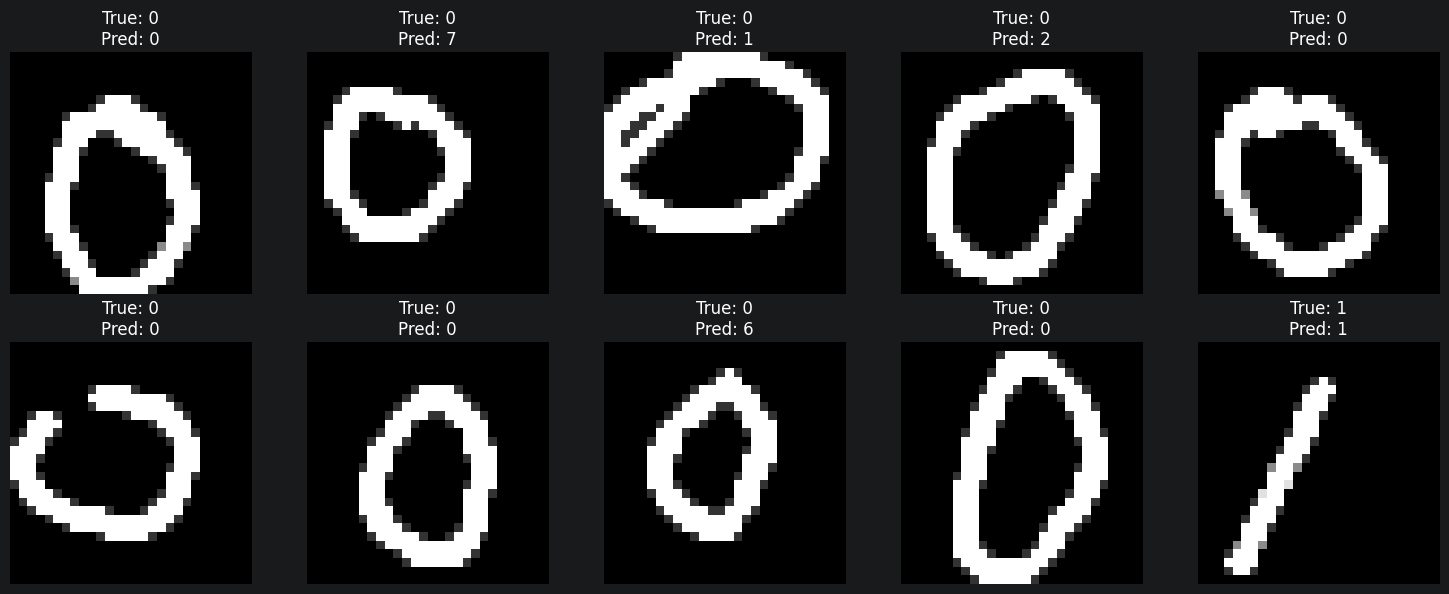

In [23]:
model.show_predictions(X_test, y_test, count=10)